# DDPG on Hopper: where the baseline actually breaks

[Pendulum](../../pendulum/README.md) showed DDPG converging tightly on all ten seeds with no
collapse and no overestimation — leaving nothing for TD3 to fix. Hopper is the environment the
TD3 paper makes its case on, and it behaves completely differently: the same implementation,
scaled from a 3-dim state and 1 action to 11 dims and 3 actions, run for 1M environment steps
across **5 seeds**.

**Result, up front:** mean greedy return of 1935 at 1M steps, per seed
`[1696, 978, 1332, 2177, 3493]`. Four of five seeds pass 3000 at some point and three of those
four end below 2500 — the collapse Pendulum did not show, here clearing the evaluation noise
floor by 3.6x. And every seed's critic overestimates its own policy's discounted return by
25-55%. That is precisely what TD3's twin critics are for.

Scoring reference: Gymnasium's `reward_threshold` for Hopper-v5 is **3800**. `healthy_reward` is
1.0 per step and episodes cap at 1000, so **~1000 means "learned not to fall" without moving** —
a local optimum, not half a solution. For comparison the TD3 paper reports roughly 1860 for DDPG
at 1M steps, which this run matches.

In [1]:
import os
import multiprocessing as mp
import random
import torch
import imageio
import numpy as np
import pandas as pd
import gymnasium as gym
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque, namedtuple
from torch.utils.tensorboard import SummaryWriter
from IPython.display import Image

In [2]:
env = gym.make("Hopper-v5", render_mode='human')

In [3]:
env.observation_space

Box(-inf, inf, (11,), float64)

In [4]:
env.action_space

Box(-1.0, 1.0, (3,), float32)

In [5]:
for _ in range(2):
    state, _ = env.reset()
    ep_reward = 0.0
    while True:

        action = env.action_space.sample()
        state, reward, done, truncated, info = env.step(action)
        ep_reward += reward
        env.render()
        if truncated or done:
            print("Reward: {}".format(ep_reward))
            break

env.close()

Reward: 17.87886929219581
Reward: 10.272090217272977


## Components

Unchanged from the Pendulum notebook apart from the shapes, which is the point — the same code
scaled up. Two things that had to change and are easy to miss:

- **`max_action` is now a constructor argument.** Hopper's action range is [-1, 1], not
  Pendulum's [-2, 2]. Hard-coding `2 * tanh(...)` would let the actor propose actions outside the
  range, which `np.clip` then silently truncates — so the critic trains on clipped actions while
  the actor optimises unclipped ones.
- **The OU noise is 3-dimensional.** A scalar noise process broadcasts across the action vector
  and perturbs every joint identically, which is one shared exploration direction rather than
  exploration.

In [6]:
class OUActionNoise:
    def __init__(self, mean, std_deviation, seed,theta=0.15, dt=.05, x_initial=None):
        np.random.seed(seed)
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        #correlated to previous noise
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        # Store x into x_prev
        # Makes next noise dependent on current one
        self.x_prev = x
        return x.astype(np.float32)

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)

In [7]:
class Replay_memory:
    '''
        The memory for storing and sampling experiences
    '''
    def __init__(self, memory_size, seed):
        random.seed(seed)
        self.memory_size = memory_size
        self.memory = deque(maxlen = memory_size)
        self.transition = namedtuple(typename='Transition', field_names= ['state', 'action', 'reward',\
                                                                          'next_state', 'done'])
    def add(self, state, action, reward, next_state, done):
        '''
            adding the experience to the memory
        '''
        self.memory.append(self.transition(state, action, reward, next_state, done))
        
    def sample(self, size, device):
        '''
            samples the experiences from the memory
        '''
        samples = random.sample(self.memory, size)
        states = torch.from_numpy(np.array([e.state for e in samples])).float().to(device)
        actions = torch.from_numpy(np.array([e.action for e in samples])).to(device)
        rewards = torch.from_numpy(np.array([e.reward for e in samples])).float().to(device).unsqueeze(1)
        next_states = torch.from_numpy(np.array([e.next_state for e in samples])).float().to(device)
        dones = torch.from_numpy(np.array([e.done for e in samples])).to(device).unsqueeze(1)
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.memory)

In [8]:
class Actor(nn.Module):

    def __init__(self,state_size, action_size, max_action =1.0,seed =0):
        super().__init__()
        self.max_action = max_action
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_size),
            nn.Tanh()
        )

    def forward(self, state):
        action = self.max_action*self.net(state)
        return action

In [9]:
class Critic(nn.Module):

    def __init__(self,state_size, action_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.fc1 = nn.Linear(state_size, 256)
        self.fc2 = nn.Linear(256 + action_size, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 1)

    def forward(self, state, action):
        out = F.relu(self.fc1(state))
        out = F.relu(self.fc2(torch.cat([out, action], dim=1)))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)
        
        return out

In [10]:
def update_target(critic_local, critic_target, actor_local, actor_target, tau):
    for local_param, target_param in zip(critic_local.parameters(), critic_target.parameters()):
        target_param.data.copy_(tau*local_param.data + (1-tau)*target_param.data)
    for local_param, target_param in zip(actor_local.parameters(), actor_target.parameters()):
        target_param.data.copy_(tau*local_param.data + (1-tau)*target_param.data)

## Evaluation

Greedy, separate env, **10 fixed start states** (`reset(seed=10_000 + i)`), every 10k environment
steps, keeping all 10 per-episode returns. Same protocol as Pendulum, and for the same reason:
fixed starts make consecutive checkpoints paired, which is what made the Pendulum interval 19x
tighter.

Note this costs real time — 100 checkpoints x 10 episodes of up to 1000 steps is up to 1M
evaluation steps against 1M training steps.

In [11]:
def evaluate(actor, device, n_eps=10, return_scores = False):
    env = gym.make("Hopper-v5")
    all_returns = []
    for i in range(n_eps):
        state, _ = env.reset(seed=10_000 + i)   # same starts at every checkpoint
        ep_return = 0.0
        while True:
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            action = actor(state_t)
            action = action.cpu().detach().squeeze().numpy()
            action = np.clip(action, env.action_space.low, env.action_space.high)
            state, reward, done, truncated, info = env.step(action)
            ep_return +=reward
            if done or truncated:
                break
        all_returns.append(ep_return)

    env.close()
    if return_scores:
        return all_returns
    return np.mean(all_returns)
    


## Configuration

Following the TD3 paper's MuJoCo settings.

| | |
|---|---|
| budget | 1M environment steps per seed, 5 seeds |
| warm-up | 25k uniformly random actions before the policy is used |
| gamma / tau | 0.99 / 5e-3 |
| learning rate | 3e-4 for both actor and critic |
| replay / batch | 1M transitions, batch 256 |
| exploration | OU noise, sigma 0.2, theta 0.15, dt 0.05 |
| evaluation | 10 fixed starts every 10k steps |

`device` is **CPU on purpose**: measured on this machine at 164 steps/s against 145 on CUDA. A
256x256 network at batch 256 is too small to fill a GPU, so kernel-launch overhead dominates —
and CPU workers avoid the "cannot re-initialise CUDA in a forked subprocess" problem below.

In [12]:
n_steps = int(1e6)
GAMMA = 0.99
TAU = 5e-3              # for soft update of target parameters
LR_ACTOR = .0003         # learning rate of the actor 
LR_CRITIC = .0003        # learning rate of the critic
memory_size = int(1e6)
batch_size = 256
noise_std = 0.2
env = gym.make("Hopper-v5")
noise_mean = np.zeros(env.action_space.shape[0]).astype(np.float32)
# measured on this machine: cpu 164 steps/s vs cuda 145 — these nets are too small to fill a GPU,
# and CPU workers also avoid the "cannot re-initialise CUDA in a forked subprocess" problem
device = torch.device('cpu')
n_workers = 5
threads_per_worker = 4

## Training loop

Step-based rather than episode-based, unlike every earlier notebook here. On Pendulum every
episode was exactly 200 steps so the two units were interchangeable; on Hopper a falling agent
ends in ~20 steps and a good one runs 1000, so an episode budget would silently expand as the
agent improved.

Two details that differ from Pendulum and are worth stating:

- **`terminated` is real here.** The hopper falls, and that is a genuine terminal state, so it is
  stored and its target is not bootstrapped. The 1000-step cap still arrives as `truncated` and
  must bootstrap. This is the first environment in the repo where both actually happen.
- **The first 25k actions are uniformly random**, not the untrained actor plus noise. With a task
  this much harder than Pendulum, bootstrapping from a narrow self-generated distribution is a
  meaningfully worse start.

In [13]:
def run(env, seed):
    env.reset(seed=seed); env.action_space.seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    noise = OUActionNoise(mean=noise_mean, std_deviation=noise_std, seed= seed)
    actor_local = Actor(env.observation_space.shape[0], env.action_space.shape[0],\
                        float(env.action_space.high[0]),seed).to(device)
    critic_local = Critic(env.observation_space.shape[0], env.action_space.shape[0], seed).to(device)

    actor_target = Actor(env.observation_space.shape[0], env.action_space.shape[0],\
                        float(env.action_space.high[0]), seed).to(device)
    critic_target = Critic(env.observation_space.shape[0], env.action_space.shape[0], seed).to(device)
    actor_target.load_state_dict(actor_local.state_dict())
    critic_target.load_state_dict(critic_local.state_dict())

    replay_memory = Replay_memory(memory_size, seed)
    optimizer_actor = torch.optim.Adam(actor_local.parameters(), LR_ACTOR)
    optimizer_critic = torch.optim.Adam(critic_local.parameters(), LR_CRITIC)

    all_rewards = []
    q_values = []
    actor_losses = []
    critic_losses = []
    recent_rewards = deque(maxlen=30)
    greedy_curve = []

    state, _ = env.reset()
    steps = 0
    ep_reward = 0
    ep_q_values = []
    ep_actor_loss = []
    ep_critic_loss = []
    

    while steps<n_steps:
        steps +=1
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        if steps < 25_000:
            action = env.action_space.sample()
        else:
            action = actor_local(state_t)
            action = action.cpu().detach().squeeze().numpy()
            action = np.clip(action + noise(), env.action_space.low, env.action_space.high)
        next_state, reward, done, truncated, info = env.step(action)
        replay_memory.add(state, action, reward, next_state, done)
        if len(replay_memory) >= 500:
            states, actions, rewards, next_states, dones = replay_memory.sample(batch_size, device)
            q_curr = critic_local(states, actions)
            with torch.no_grad():
                next_actions = actor_target(next_states)
                q_next = critic_target(next_states, next_actions)
                target = rewards + GAMMA* q_next*(1-dones*1.0)
        
            loss_critic = F.mse_loss(q_curr, target)
            optimizer_critic.zero_grad()
            loss_critic.backward()
            optimizer_critic.step()
            ep_q_values.append(q_curr.mean().item())
            ep_critic_loss.append(loss_critic.item())

            actions_pred = actor_local(states) 
            actor_loss = -critic_local(states, actions_pred).mean()
            optimizer_actor.zero_grad()
            actor_loss.backward()
            optimizer_actor.step() 
            ep_actor_loss.append(actor_loss.item())


        state = next_state
        ep_reward += reward
        update_target(critic_local, critic_target, actor_local, actor_target, TAU)
        if done or truncated:
            noise.reset() 
            recent_rewards.append(ep_reward)
            all_rewards.append(ep_reward)
            # NaN for warm-up episodes with no updates, so every array lines up with all_rewards
            q_values.append(np.mean(ep_q_values) if ep_q_values else np.nan)
            actor_losses.append(np.mean(ep_actor_loss) if ep_actor_loss else np.nan)
            critic_losses.append(np.mean(ep_critic_loss) if ep_critic_loss else np.nan)
            ep_reward = 0
            ep_q_values = []
            ep_actor_loss = []
            ep_critic_loss = []
            state, _ = env.reset()
            

        if steps%10000==0:
            eval_scores = evaluate(actor_local, device, return_scores=True)   # all 10 episodes, not the mean
            greedy_curve.append(eval_scores)
            print(f'[seed {seed}] step {steps:>7,}  greedy {np.mean(eval_scores):8.1f}  '
                  f'train {np.mean(recent_rewards) if recent_rewards else float("nan"):8.1f}', flush=True)

    # identical to greedy_curve[-1]: same actor, same fixed eval seeds, deterministic policy
    greedy_eval = evaluate(actor_local, device, return_scores=True)


    return all_rewards, q_values, actor_losses, critic_losses, greedy_eval, greedy_curve, actor_local
            

## Running 5 seeds in parallel

The seeds are independent, so they run as five OS processes rather than sequentially. `fork` lets
the workers inherit the notebook-defined `run`, `Actor` and `Critic` directly; each builds its own
env, sets its own thread count, and writes its own result file.

One file per seed matters for two reasons: episode counts differ between seeds (5064 to 6300
here), so the per-episode arrays cannot be stacked into one rectangular array, and a crash in hour
eight costs one seed instead of the sweep.

Measured wall clock: about **10 hours** for all five in parallel — well over the ~3.5 h estimated
beforehand. The gap is the replay buffer: `random.sample` on a `deque` indexes into the middle,
which is O(n), so its cost grows as the buffer fills (0.18 ms at 30k entries, 14.1 ms at 1M).
Pre-allocated NumPy arrays sample in 0.49 ms at 1M and would cut hours from the run.

In [14]:
seeds = list(range(5))
os.makedirs("results", exist_ok=True)


def run_and_save(seed):
    """One seed, in its own process: own env, own torch threads, own result file."""
    torch.set_num_threads(threads_per_worker)
    env = gym.make("Hopper-v5")
    all_rewards, q_vals, a_loss, c_loss, greedy_eval, greedy_curve, actor = run(env, seed)

    # one file per seed: survives a crash mid-sweep, and sidesteps the ragged-array problem
    # (episode counts differ by seed, so the per-episode arrays cannot be stacked)
    np.savez(f"results/ddpg_seed{seed}.npz",
             scores       = np.array(all_rewards,  np.float32),   # (n_episodes,)  varies by seed
             q_values     = np.array(q_vals,       np.float32),
             actor_loss   = np.array(a_loss,       np.float32),
             critic_loss  = np.array(c_loss,       np.float32),
             greedy_eval  = np.array(greedy_eval,  np.float32),   # (10,)
             greedy_curve = np.array(greedy_curve, np.float32))   # (n_checkpoints, 10)
    torch.save(actor.state_dict(), f"results/ddpg_actor_seed{seed}.pth")
    env.close()
    return seed, len(all_rewards), float(np.mean(greedy_eval))


# fork so the workers inherit these notebook-defined functions; CPU-only, so no CUDA context to clash
with mp.get_context("fork").Pool(n_workers) as pool:
    for seed, n_eps, final in pool.imap_unordered(run_and_save, seeds):
        print(f"--- seed {seed} finished: {n_eps} episodes, final greedy {final:.1f}", flush=True)

[seed 1] step  10,000  greedy     58.5  train     13.4
[seed 0] step  10,000  greedy    182.4  train     23.2
[seed 2] step  10,000  greedy     38.0  train     15.2
[seed 4] step  10,000  greedy    104.3  train     14.8
[seed 2] step  20,000  greedy    157.3  train     10.8
[seed 2] step  30,000  greedy     -2.6  train     40.6
[seed 4] step  20,000  greedy     -2.9  train     16.9
[seed 2] step  40,000  greedy   1004.3  train    351.8
[seed 1] step  20,000  greedy    201.8  train     17.7
[seed 2] step  50,000  greedy    503.1  train    267.5
[seed 3] step  10,000  greedy     99.2  train     19.4
[seed 1] step  30,000  greedy     -2.3  train     -2.2
[seed 3] step  20,000  greedy      6.5  train     18.4
[seed 1] step  40,000  greedy      6.8  train      5.5
[seed 0] step  20,000  greedy    129.9  train     15.9
[seed 3] step  30,000  greedy    168.5  train    168.9
[seed 0] step  30,000  greedy    198.1  train    192.3
[seed 2] step  60,000  greedy     16.7  train     43.9
[seed 3] s

## Loading the results

In [15]:
runs = [np.load(f"results/ddpg_seed{s}.npz") for s in seeds]

G = np.stack([r["greedy_curve"] for r in runs])          # (seeds, checkpoints, eval episodes)
eval_steps = (np.arange(G.shape[1]) + 1) * 10_000        # checkpoints are every 10k env steps

# per-episode arrays are ragged across seeds -> pad to the longest with NaN for plotting
n = max(len(r["scores"]) for r in runs)
def padded(key):
    A = np.full((len(runs), n), np.nan, np.float32)
    for i, r in enumerate(runs): A[i, :len(r[key])] = r[key]
    return A

scores, q_values = padded("scores"), padded("q_values")
actor_loss, critic_loss = padded("actor_loss"), padded("critic_loss")

print("greedy curve :", G.shape)
print("episodes per seed:", [len(r["scores"]) for r in runs])
print(f"final greedy return: {G[:, -1].mean():.1f} "
      f"(per seed: {np.round(G[:, -1].mean(axis=1), 1)})")

greedy curve : (5, 100, 10)
episodes per seed: [5477, 5949, 5064, 5744, 6300]
final greedy return: 1935.2 (per seed: [1695.6  978.2 1331.9 2176.9 3493.2])


## Training curves

A caveat on these three plots: the x-axis is episode *index*, and episodes are not aligned in time
across seeds — a seed with 6300 episodes reached its 3000th much earlier than a seed with 5064.
Averaging across seeds at a fixed episode index therefore mixes different points in training. The
greedy curve below, indexed by environment step, is the one to read for progress; these are for
the shape of the loss and Q traces.

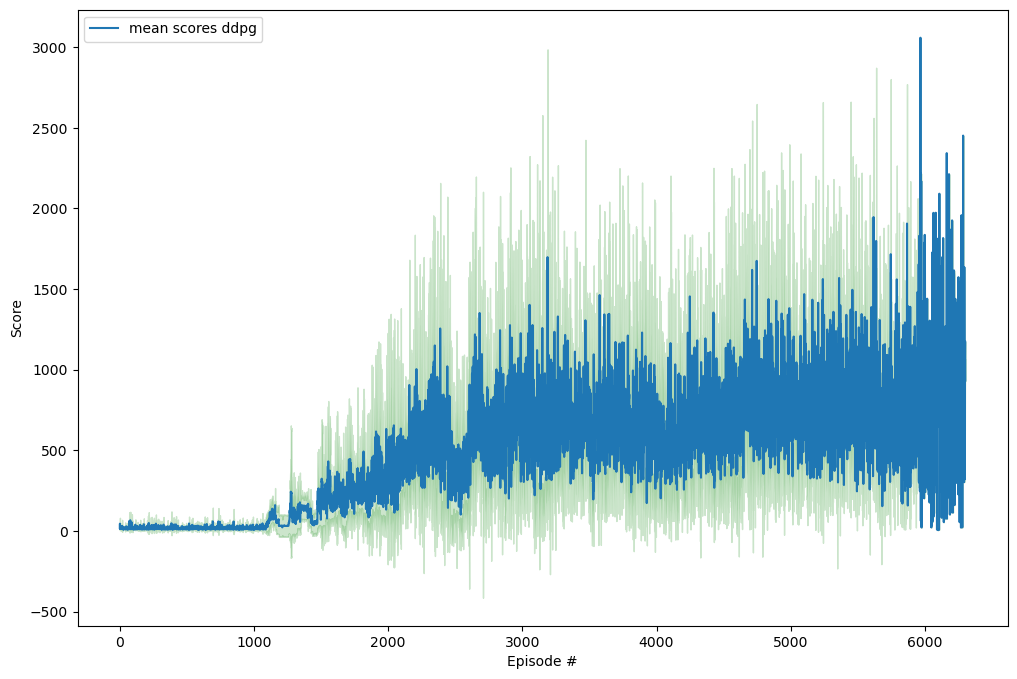

In [16]:
plt.figure(figsize=(12,8))
mean = np.nanmean(scores, axis =0)
std = np.nanstd(scores, axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean scores ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('Score')
plt.show()

/tmp/ipykernel_155599/545970611.py:2: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(q_values, axis =0)
/home/neeraj/anaconda3/envs/gym/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


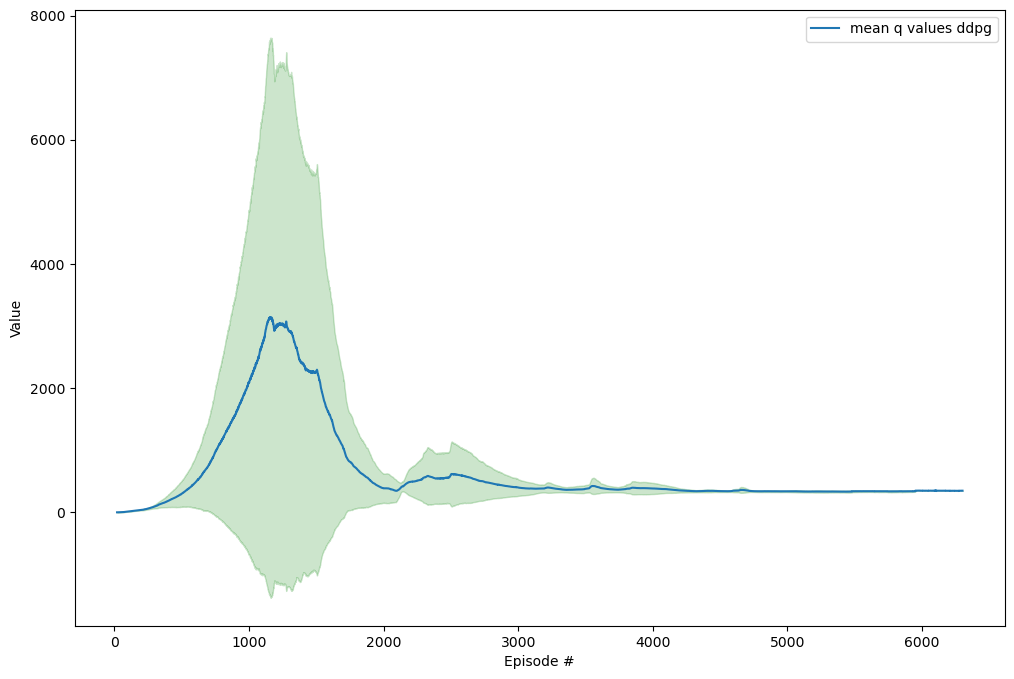

In [17]:
plt.figure(figsize=(12,8))
mean = np.nanmean(q_values, axis =0)
std = np.nanstd(q_values, axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean q values ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('Value')
plt.show()

/tmp/ipykernel_155599/964366744.py:2: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(actor_loss, axis =0)


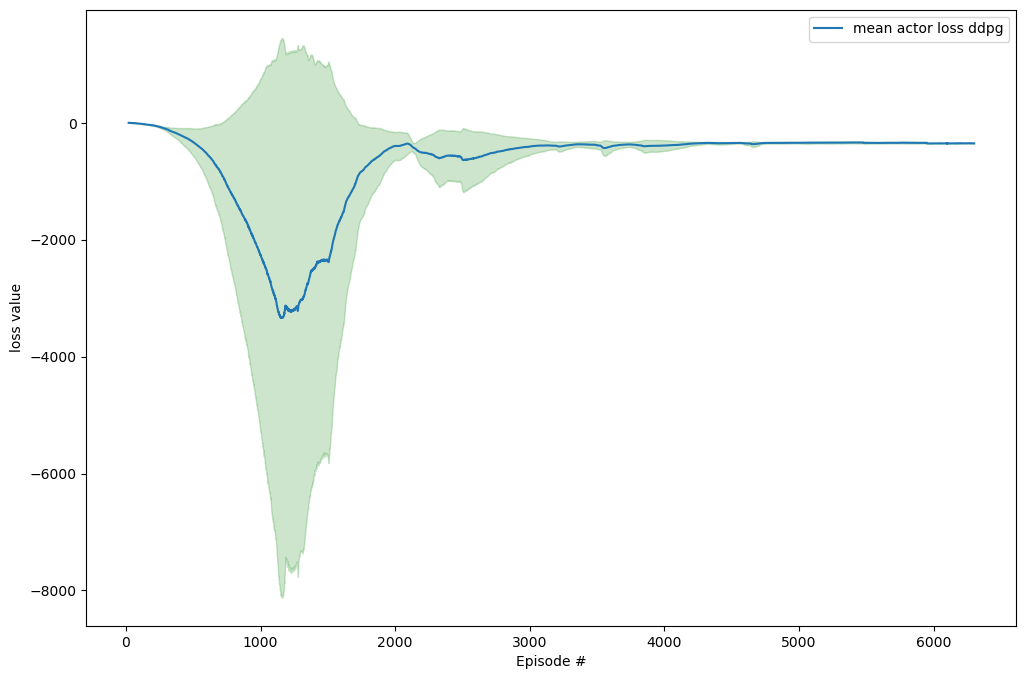

In [18]:
plt.figure(figsize=(12,8))
mean = np.nanmean(actor_loss, axis =0)
std = np.nanstd(actor_loss, axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean actor loss ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('loss value')
plt.show()

/tmp/ipykernel_155599/728319986.py:2: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(critic_loss, axis =0)


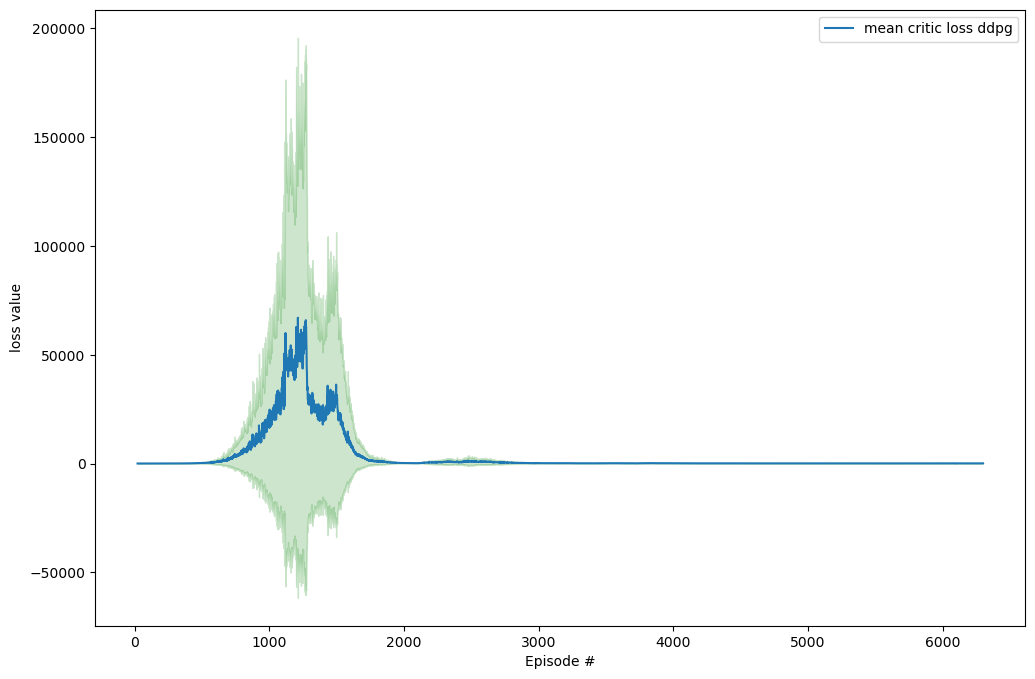

In [19]:
plt.figure(figsize=(12,8))
mean = np.nanmean(critic_loss, axis =0)
std = np.nanstd(critic_loss, axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean critic loss ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('loss value')
plt.show()

## Greedy evaluation, and whether the swings are real

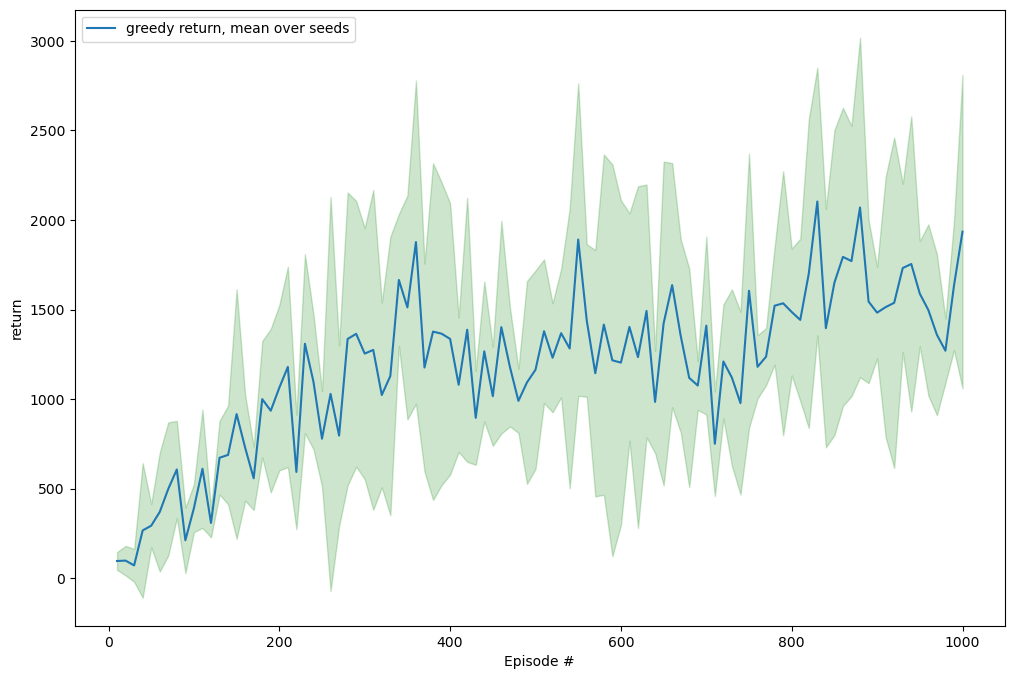

In [20]:
per_seed = G.mean(axis=2)                   # average the 10 eval episodes -> (seeds, checkpoints)
mean = per_seed.mean(axis=0)
std = per_seed.std(axis=0)
x = (np.arange(len(mean)) + 1) * 10_000     # one checkpoint every 10k environment steps

plt.figure(figsize=(12,8))
plt.plot(x, mean, label='greedy return, mean over seeds')
plt.fill_between(x, mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Environment step')
plt.ylabel('return')
plt.show()

In [21]:
# --- is the swinging real, or evaluation noise? ---
within = G[:, 50:].std(axis=2, ddof=1).mean() / np.sqrt(G.shape[2])   # SE of one checkpoint
across = np.abs(np.diff(per_seed[:, 50:], axis=1)).mean()             # typical jump between checkpoints
print(f"SE of a single checkpoint (10 eval episodes) : {within:7.1f}")
print(f"mean |change| between adjacent checkpoints   : {across:7.1f}  ({across/within:.1f}x the noise floor)\n")

for i in range(len(runs)):
    c = per_seed[i, 50:]; pk = int(np.argmax(per_seed[i]))
    print(f"  seed {i}: best {per_seed[i, pk]:6.0f} @ {(pk+1)*10}k | final {per_seed[i,-1]:6.0f} | "
          f"2nd-half range {c.min():5.0f}-{c.max():5.0f} | below 1500 in {(c<1500).mean():4.0%} of checkpoints")

ever = (per_seed > 3000).any(1)
print(f"\nseeds that ever exceeded 3000: {ever.sum()}/{len(runs)}; "
      f"of those, ended below 2500: {((per_seed[:,-1] < 2500) & ever).sum()}/{ever.sum()}")

SE of a single checkpoint (10 eval episodes) :   150.6
mean |change| between adjacent checkpoints   :   548.3  (3.6x the noise floor)

  seed 0: best   3438 @ 860k | final   1696 | 2nd-half range    25- 3438 | below 1500 in  68% of checkpoints
  seed 1: best   1799 @ 650k | final    978 | 2nd-half range   703- 1799 | below 1500 in  86% of checkpoints
  seed 2: best   3333 @ 550k | final   1332 | 2nd-half range   361- 3333 | below 1500 in  76% of checkpoints
  seed 3: best   3227 @ 380k | final   2177 | 2nd-half range   341- 2739 | below 1500 in  64% of checkpoints
  seed 4: best   3493 @ 1000k | final   3493 | 2nd-half range   318- 3493 | below 1500 in  30% of checkpoints

seeds that ever exceeded 3000: 4/5; of those, ended below 2500: 3/4


In [22]:
# --- is the critic overestimating? roll out the saved actors and discount properly ---
eval_env = gym.make("Hopper-v5")
print("seed | undiscounted | true discounted | logged mean Q | ratio")
for s in seeds:
    a = Actor(11, 3, 1.0, s).to(device)
    a.load_state_dict(torch.load(f"results/ddpg_actor_seed{s}.pth")); a.eval()
    und, disc = [], []
    for i in range(10):
        st, _ = eval_env.reset(seed=10_000 + i); R = D = 0.0; k = 0
        while True:
            with torch.no_grad():
                act = a(torch.tensor(st, dtype=torch.float32).unsqueeze(0).to(device)).squeeze(0).cpu().numpy()
            st, r, term, trunc, _ = eval_env.step(np.clip(act, -1, 1))
            R += r; D += (GAMMA ** k) * r; k += 1
            if term or trunc: break
        und.append(R); disc.append(D)
    q = runs[s]["q_values"][~np.isnan(runs[s]["q_values"])][-50:].mean()
    print(f"  {s}  |   {np.mean(und):8.0f}   |    {np.mean(disc):8.0f}      |   {q:7.0f}     | {q/np.mean(disc):.2f}x")
eval_env.close()

# caveat: logged Q averages over replay states from a mixture of past policies, while the
# discounted return starts from the 10 fixed eval states under the final policy. Indicative,
# not exact - saving the critic would let TD3's comparison use identical states.

seed | undiscounted | true discounted | logged mean Q | ratio
  0  |       1829   |         234      |       316     | 1.35x
  1  |        982   |         254      |       330     | 1.30x
  2  |       1255   |         263      |       339     | 1.29x
  3  |       2502   |         221      |       343     | 1.55x
  4  |       3272   |         278      |       347     | 1.25x


## Findings

**1. DDPG is unstable on Hopper, and it is not a measurement artefact.** Adjacent checkpoints
differ by 3.6x the standard error of a single checkpoint, so the swings are genuine policy change.
Four of five seeds exceed 3000 and three of those end below 2500; seed 2 falls from 3333 to 361 —
a competent hopper reduced to falling over. On Pendulum the apparent collapse turned out to be
selection bias in the metric; here the effect clears the noise floor by a wide margin.

**2. The critic overestimates its own policy by 25-55%.** Logged mean Q at the end of training is
nearly identical across seeds (316 to 347) while actual performance differs 3.5-fold. Rolling out
the saved actors and discounting properly shows every seed's critic above the return its policy
achieves. This is the bias TD3's twin critics target, and it is the first time in this repo it has
been *measured* rather than bounded — Pendulum's `Q <= 0` ceiling could only catch a critic that
was provably broken, not one that was merely optimistic.

**3. The result matches the literature.** Mean 1935 at 1M steps against roughly 1860 reported for
DDPG in the TD3 paper, and well short of Gymnasium's 3800 threshold.

## Next: TD3

Three changes to this code — twin critics taking the minimum, delayed actor updates, and target
policy smoothing — with everything else held fixed, on the same 5 seeds and the same fixed
evaluation starts.

One thing to add for that run: **save the critic as well as the actor**. The overestimation table
above compares Q averaged over replay states from a mixture of past policies against discounted
returns from the fixed eval states under the final policy. It is indicative, but with the critic
saved both sides can be computed on identical states, which is the comparison worth reporting.